In [1]:
from datasets import load_dataset

ds = load_dataset("restor/tcd")

C:\Users\plesi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
import tensorflow as tf
tf.config.threading.set_intra_op_parallelism_threads(0)


@tf.keras.utils.register_keras_serializable(package="Custom", name="Unet")
class Unet(tf.keras.Model):
    def __init__(self, **kwargs):
        super(Unet, self).__init__(**kwargs)

        # First encoder layer
        self.enc1_1 = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')
        self.enc1_2 = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')
        self.pool1  = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)

        # Second encoder layer
        self.enc2_1 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')
        self.enc2_2 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')
        self.pool2  = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)

        # Third encoder layer
        self.enc3_1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')
        self.enc3_2 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')
        self.pool3  = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)

        # Bottleneck
        self.bottl1 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')
        self.bottl2 = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')

        # First decoder layer
        self.dec1_transpose = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')
        self.dec1_1         = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')
        self.dec1_2         = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')

        # Second decoder layer
        self.dec2_transpose = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')
        self.dec2_1         = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')
        self.dec2_2         = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')

        # Third decoder layer
        self.dec3_transpose = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=2, padding='same')
        self.dec3_1         = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')
        self.dec3_2         = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')

        self.final = tf.keras.layers.Conv2D(1, 1, padding='same', activation='sigmoid')

        self.concat = tf.keras.layers.Concatenate(axis=-1)

    def call(self, inputs):
        # Encoder 1
        x = self.enc1_1(inputs)
        x = self.enc1_2(x)
        enc1_out = self.pool1(x)

        # Encoder 2
        x = self.enc2_1(enc1_out)
        x = self.enc2_2(x)
        enc2_out = self.pool2(x)

        # Encoder 3
        x = self.enc3_1(enc2_out)
        x = self.enc3_2(x)
        enc3_out = self.pool3(x)

        # Bottleneck
        x = self.bottl1(enc3_out)
        bottl1_out = self.bottl2(x)

        # Decoder 1
        x = self.dec1_transpose(bottl1_out)
        skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(enc3_out)
        x = tf.keras.layers.Concatenate()([x, skip_features])

        x = self.dec1_1(x)
        dec1_out = self.dec1_2(x)

        # Decoder 2
        x = self.dec2_transpose(dec1_out)
        skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(enc2_out)
        x = tf.keras.layers.Concatenate()([x, skip_features])

        x = self.dec2_1(x)
        dec2_out = self.dec2_2(x)

        # Decoder 3
        x = self.dec3_transpose(dec2_out)
        skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(enc1_out)
        x = tf.keras.layers.Concatenate()([x, skip_features])

        x = self.dec3_1(x)
        dec3_out = self.dec3_2(x)

        output = self.final(dec3_out)

        return output

    def get_config(self):
        base_config = super(Unet, self).get_config()
        return base_config


In [41]:
import cv2
import numpy as np
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(0)
    
def create_mask_from_annotations(example):
    annotation = example.get('annotation', [])
    annotation = np.array(annotation)
    mask = np.array(cv2.cvtColor(annotation, cv2.COLOR_BGR2GRAY) / 255 > 0.001, dtype=np.uint8)
        
    return cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST).reshape((512, 512, 1))

def generator(dataset):
    for example in dataset:
        image = np.array(example['image'].convert('RGB').resize((512, 512)))/255.0
        mask = create_mask_from_annotations(example)

        yield tf.convert_to_tensor(image, dtype=tf.float32), tf.convert_to_tensor(mask, dtype=tf.float32)

train_ds = ds['train']
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator(train_ds),
    output_signature=(
         tf.TensorSpec(shape=(512, 512, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(512, 512, 1), dtype=tf.float32)
    )
)

train_dataset = train_dataset.cache()
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

test_ds = ds['test']
test_dataset = tf.data.Dataset.from_generator(
    lambda: generator(test_ds),
    output_signature=(
         tf.TensorSpec(shape=(512, 512, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(512, 512, 1), dtype=tf.float32)
    )
)

test_dataset = test_dataset.cache()
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)


In [42]:
model = Unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)])
model.fit(train_dataset.batch(batch_size=8), epochs=4)

Epoch 1/4


C:\Users\plesi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'unet_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


522/522 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.7605 - binary_io_u: 0.3079 - loss: 0.4716
Epoch 2/4


C:\Users\plesi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


522/522 ━━━━━━━━━━━━━━━━━━━━ 697s 1s/step - accuracy: 0.7923 - binary_io_u: 0.4408 - loss: 0.4339
Epoch 3/4
522/522 ━━━━━━━━━━━━━━━━━━━━ 893s 2s/step - accuracy: 0.8168 - binary_io_u: 0.4712 - loss: 0.4076
Epoch 4/4
522/522 ━━━━━━━━━━━━━━━━━━━━ 711s 1s/step - accuracy: 0.8355 - binary_io_u: 0.5172 - loss: 0.3805


In [ ]:
model.fit(train_dataset.batch(batch_size=8), epochs=4, )

In [43]:
model.evaluate(test_dataset.batch(batch_size=8))

55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8651 - binary_io_u: 0.5713 - loss: 0.3234


[0.3233858048915863, 0.865126371383667, 0.5713443756103516]

In [44]:
test = np.array(ds['test'][99]['image'].convert('RGB').resize((512, 512)))/255.0
pred = model.predict(tf.convert_to_tensor([test], dtype=tf.float32))
cv2_mask = (pred[0] > 0.5).astype(np.uint8) * 255

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


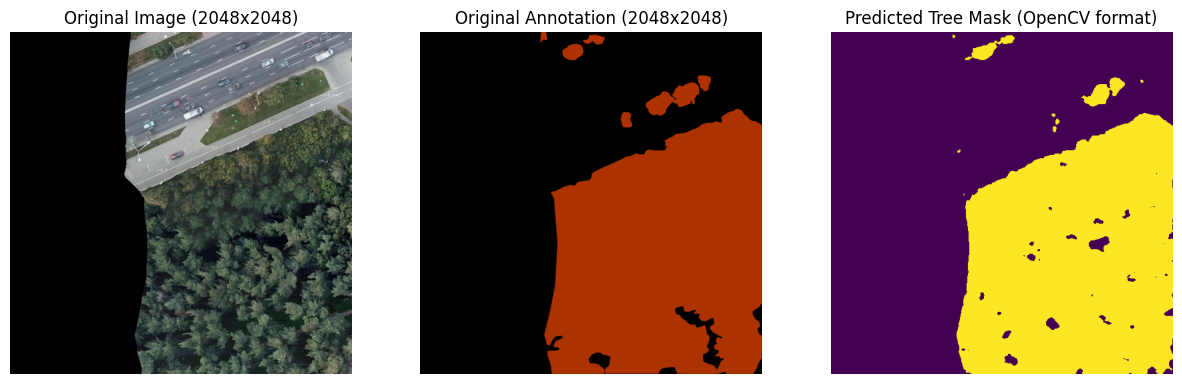

In [45]:
import matplotlib.pyplot as plt

# Visualize the result
plt.figure(figsize=(15, 7))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(ds['test'][99]['image'].convert('RGB').resize((512, 512)))
plt.title("Original Image (2048x2048)")
plt.axis("off")

# Original Annotation
plt.subplot(1, 3, 2)
plt.imshow(ds['test'][99]['annotation'].convert('RGB').resize((512, 512)))
plt.title("Original Annotation (2048x2048)")
plt.axis("off")

# Predicted Mask
plt.subplot(1, 3, 3)
# Reshape or squeeze the mask if needed for display
plt.imshow(cv2_mask.squeeze())
plt.title("Predicted Tree Mask (OpenCV format)")
plt.axis("off")

plt.show()

In [46]:
model.save('../models/tree_mask_autoencoder_model.keras')

In [47]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model('../models/tree_mask_autoencoder_model.keras')

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

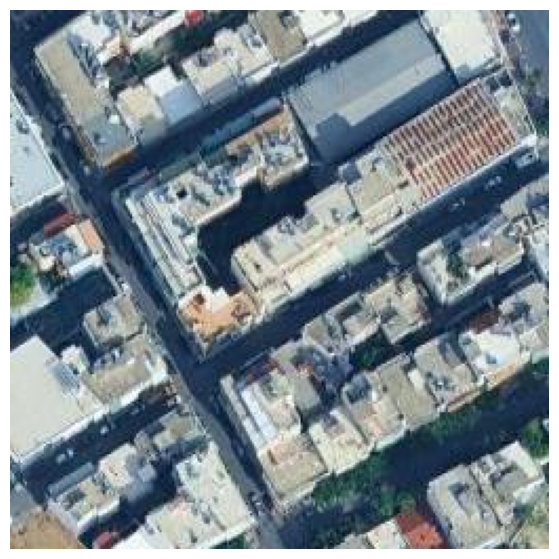

In [62]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

image = cv2.imread('../.tile_cache/18_148338_101121.png')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')


In [63]:
import numpy as np
import cv2

input_tensor = np.expand_dims(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), axis=0) / 255.0

pred = loaded_model.predict(input_tensor)[0]
mask = (pred > 0.5).astype(np.uint8) * 255

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [64]:
image.shape, mask.shape

((256, 256, 3), (256, 256, 1))

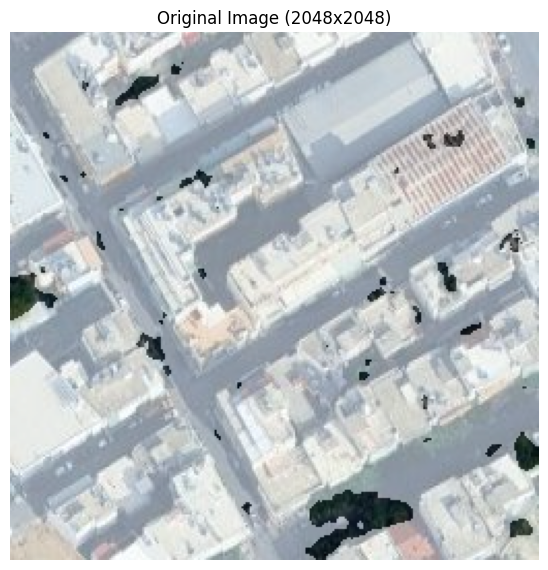

In [65]:
import matplotlib.pyplot as plt

# Visualize the result
plt.figure(figsize=(15, 7))

masked_image = cv2.addWeighted(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), 0.5, cv2.cvtColor(cv2.bitwise_not(mask), cv2.COLOR_GRAY2RGB), 0.5, 0)

plt.subplot(1, 2, 1)
plt.imshow(masked_image)
plt.title("Original Image (2048x2048)")
plt.axis("off")

plt.show()

In [66]:
sum(sum(mask.squeeze() > 0.5))/(mask.shape[0] * mask.shape[1])

np.float64(0.033599853515625)